In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import mplfinance as mpf

# Suppress pandas warnings
pd.options.mode.chained_assignment = None

# Make notebook full width
display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['figure.figsize'] = (24, 10) # Set default matplotlib size to full wide

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading (Small Sample)
SAMPLE_STOCKS = ['360ONE', '3MINDIA', 'AARTIIND', 'ABB', 'ACC']

def load_data(stocks):
    all_data = []
    for symbol in stocks:
        file_path = os.path.join(DATA_DIR, f"{symbol}.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date')
            df['Symbol'] = symbol
            all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

data = load_data(SAMPLE_STOCKS)


In [3]:
# 3. Pattern Definition: Bullish Rejection Wick
def detect_bullish_rejection(df):
    df = df.copy()
    df['Body'] = abs(df['Close'] - df['Open'])
    df['Upper_Wick'] = df['High'] - df[['Open', 'Close']].max(axis=1)
    df['Lower_Wick'] = df[['Open', 'Close']].min(axis=1) - df['Low']
    
    condition1 = df['Lower_Wick'] >= (2.5 * df['Body'])
    condition2 = df['Upper_Wick'] < df['Body']
    df['Is_Rejection'] = condition1 & condition2
    return df

processed_data = detect_bullish_rejection(data)


In [4]:
# 4. Feature Engineering: WMA and ER Regimes
def compute_regimes(df, periods=[3, 13, 21, 55]):
    df = df.copy()
    for p in periods:
        # WMA
        weights = np.arange(1, p + 1)
        wma = df.groupby('Symbol')['Close'].rolling(p).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True).reset_index(level=0, drop=True)
        df[f'WMA_Dist_{p}'] = (df['Close'] - wma) / wma
        # ER
        change = abs(df['Close'] - df.groupby('Symbol')['Close'].shift(p))
        volatility = df.groupby('Symbol')['Close'].diff().abs().rolling(p).sum()
        df[f'ER_{p}'] = change / volatility
    return df

processed_data = compute_regimes(processed_data)


In [5]:
# 5. Forward Returns & Analysis
FORWARD_DAYS = 5
processed_data[f'Fwd_Return_{FORWARD_DAYS}d'] = processed_data.groupby('Symbol')['Close'].shift(-FORWARD_DAYS) / processed_data['Close'] - 1

signals = processed_data[processed_data['Is_Rejection'] == True].copy()
signals = signals.dropna(subset=[f'Fwd_Return_{FORWARD_DAYS}d'])

features = [f'WMA_Dist_{p}' for p in [3, 13, 21, 55]] + [f'ER_{p}' for p in [3, 13, 21, 55]]
signals = signals.dropna(subset=features)


In [6]:
# 6. Trade Profiling via Decision Tree
X = signals[features]
y = (signals[f'Fwd_Return_{FORWARD_DAYS}d'] > 0).astype(int)

clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
clf.fit(X, y)

signals['ML_Prediction'] = clf.predict(X)
print(export_text(clf, feature_names=features))


|--- ER_13 <= 0.52
|   |--- ER_3 <= 0.18
|   |   |--- WMA_Dist_3 <= -0.00
|   |   |   |--- class: 1
|   |   |--- WMA_Dist_3 >  -0.00
|   |   |   |--- class: 1
|   |--- ER_3 >  0.18
|   |   |--- ER_13 <= 0.41
|   |   |   |--- class: 0
|   |   |--- ER_13 >  0.41
|   |   |   |--- class: 1
|--- ER_13 >  0.52
|   |--- ER_3 <= 0.93
|   |   |--- ER_3 <= 0.50
|   |   |   |--- class: 0
|   |   |--- ER_3 >  0.50
|   |   |   |--- class: 0
|   |--- ER_3 >  0.93
|   |   |--- class: 0



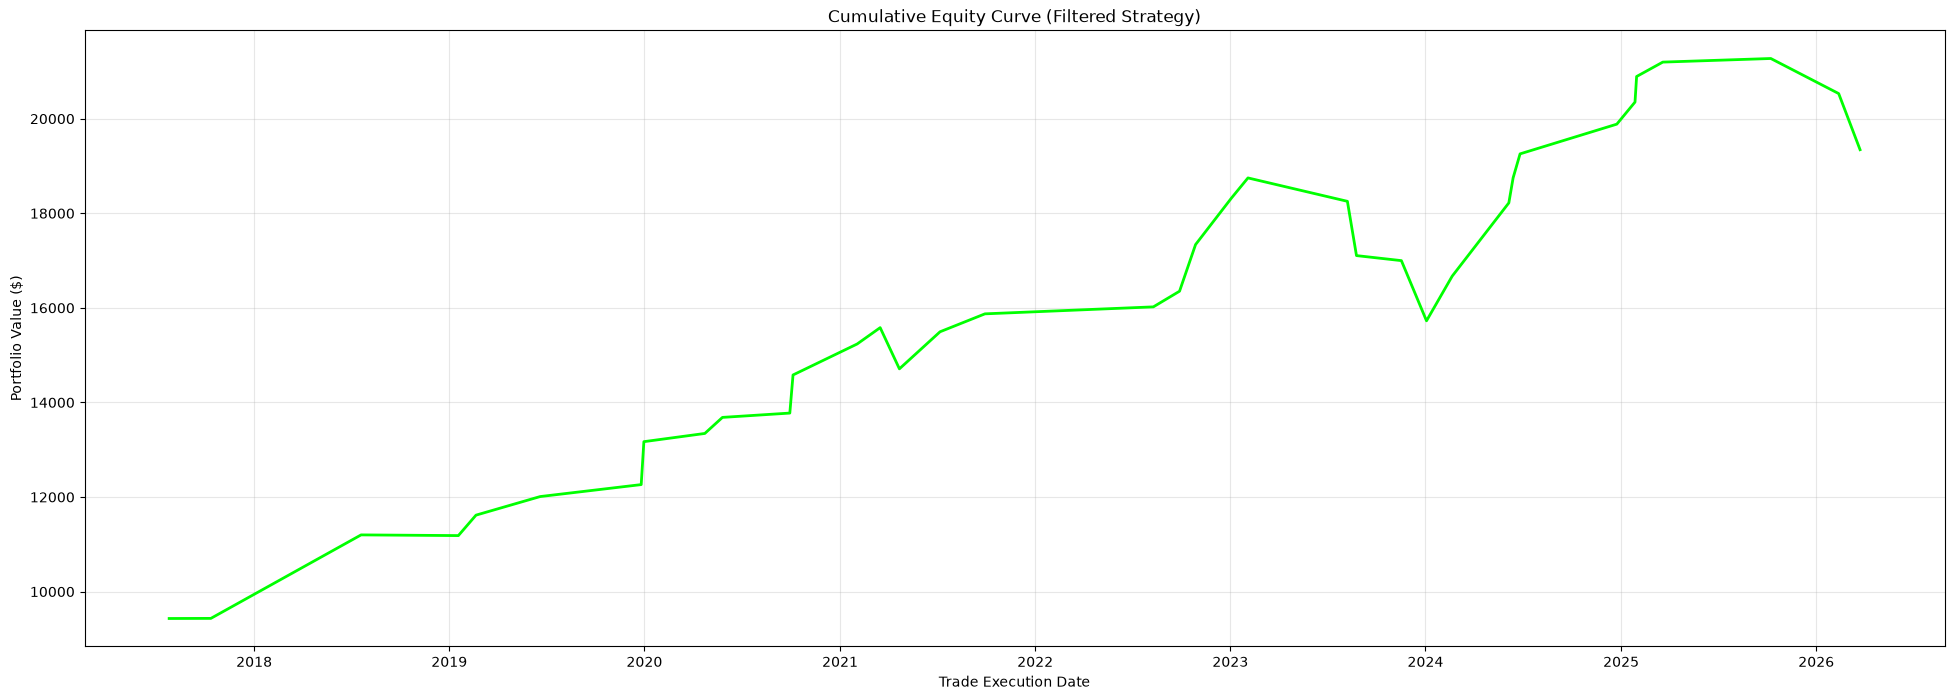

In [7]:
# 7. Proper Backtesting (Cumulative Equity Curve)
filtered_signals = signals[signals['ML_Prediction'] == 1].copy()
filtered_signals = filtered_signals.sort_values('Date').reset_index(drop=True)

# Calculate equity curve assuming $10k starting capital, equal weighting per trade
STARTING_CAPITAL = 10000
filtered_signals['Equity'] = STARTING_CAPITAL * (1 + filtered_signals[f'Fwd_Return_{FORWARD_DAYS}d']).cumprod()
filtered_signals['Drawdown'] = (filtered_signals['Equity'] / filtered_signals['Equity'].cummax()) - 1

total_filtered = len(filtered_signals)
win_rate_filtered = (filtered_signals[f'Fwd_Return_{FORWARD_DAYS}d'] > 0).mean() * 100
final_equity = filtered_signals['Equity'].iloc[-1] if total_filtered > 0 else STARTING_CAPITAL
max_drawdown = filtered_signals['Drawdown'].min() * 100 if total_filtered > 0 else 0

display(HTML(f"<h3>Backtest Results</h3><ul><li>Trades: {total_filtered}</li><li>Win Rate: {win_rate_filtered:.1f}%</li><li>Final Equity: ${final_equity:,.2f}</li><li>Max Drawdown: {max_drawdown:.2f}%</li></ul>"))

plt.figure(figsize=(24, 8))
plt.plot(filtered_signals['Date'], filtered_signals['Equity'], color='lime', linewidth=2)
plt.title("Cumulative Equity Curve (Filtered Strategy)")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Trade Execution Date")
plt.grid(True, alpha=0.3)
plt.show()


findfont: Failed to find font weight semibold, now using 700.


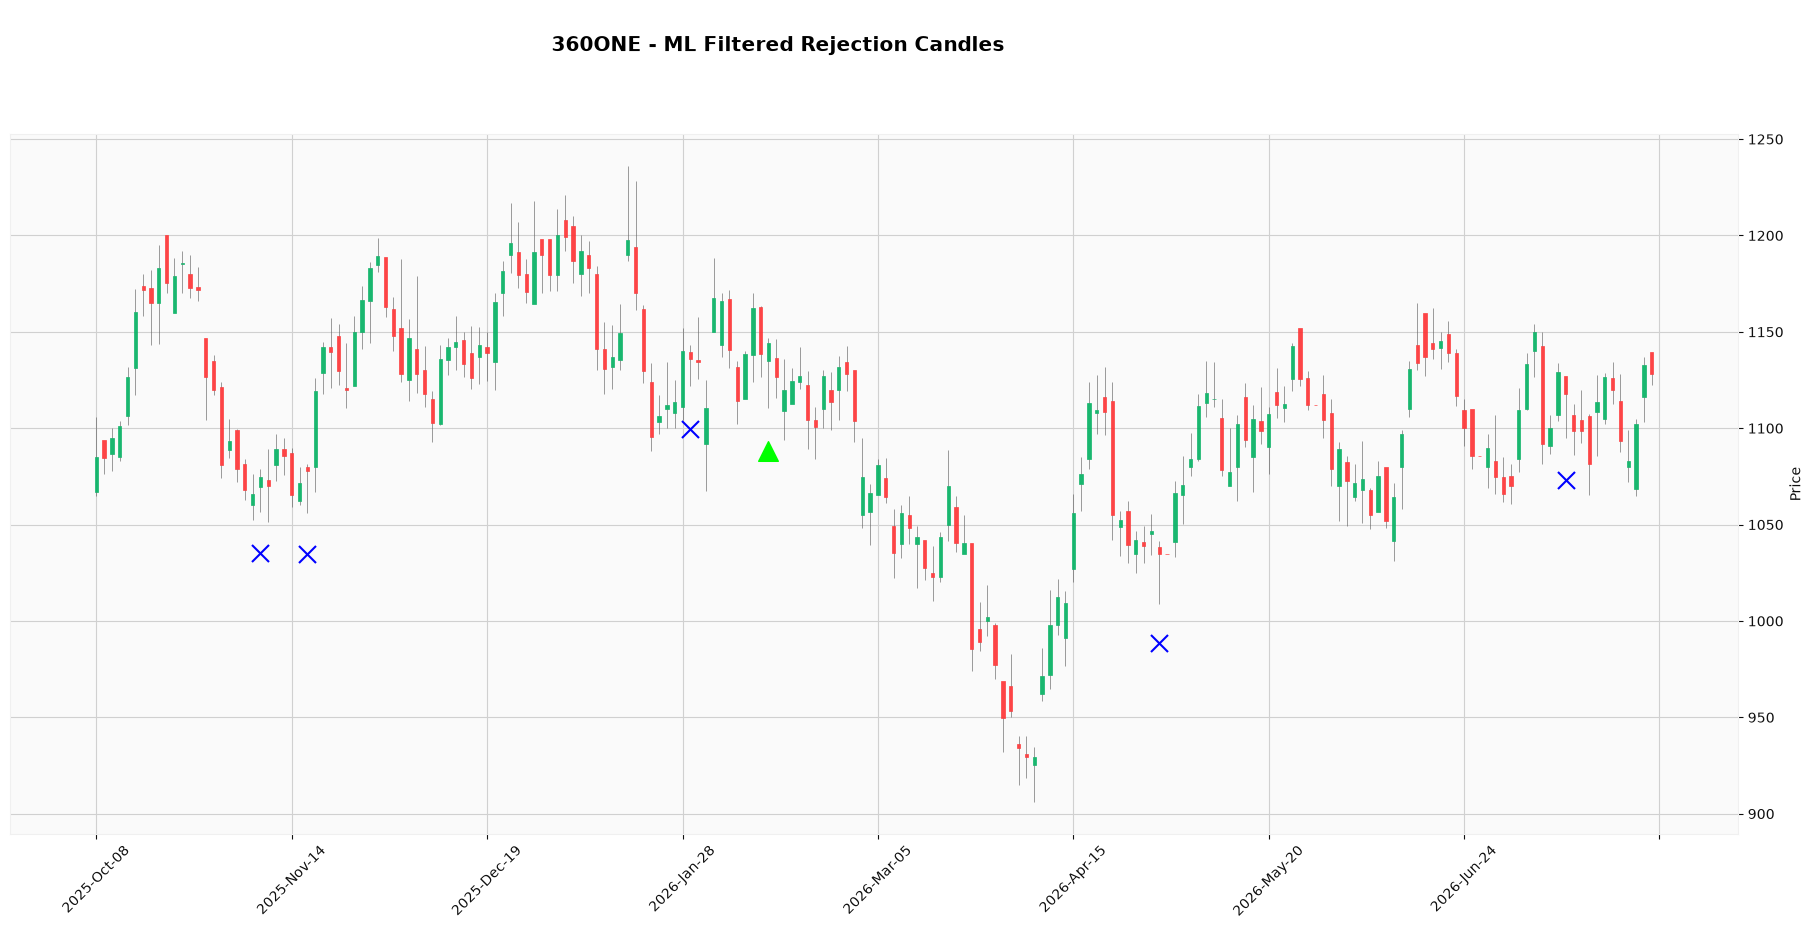

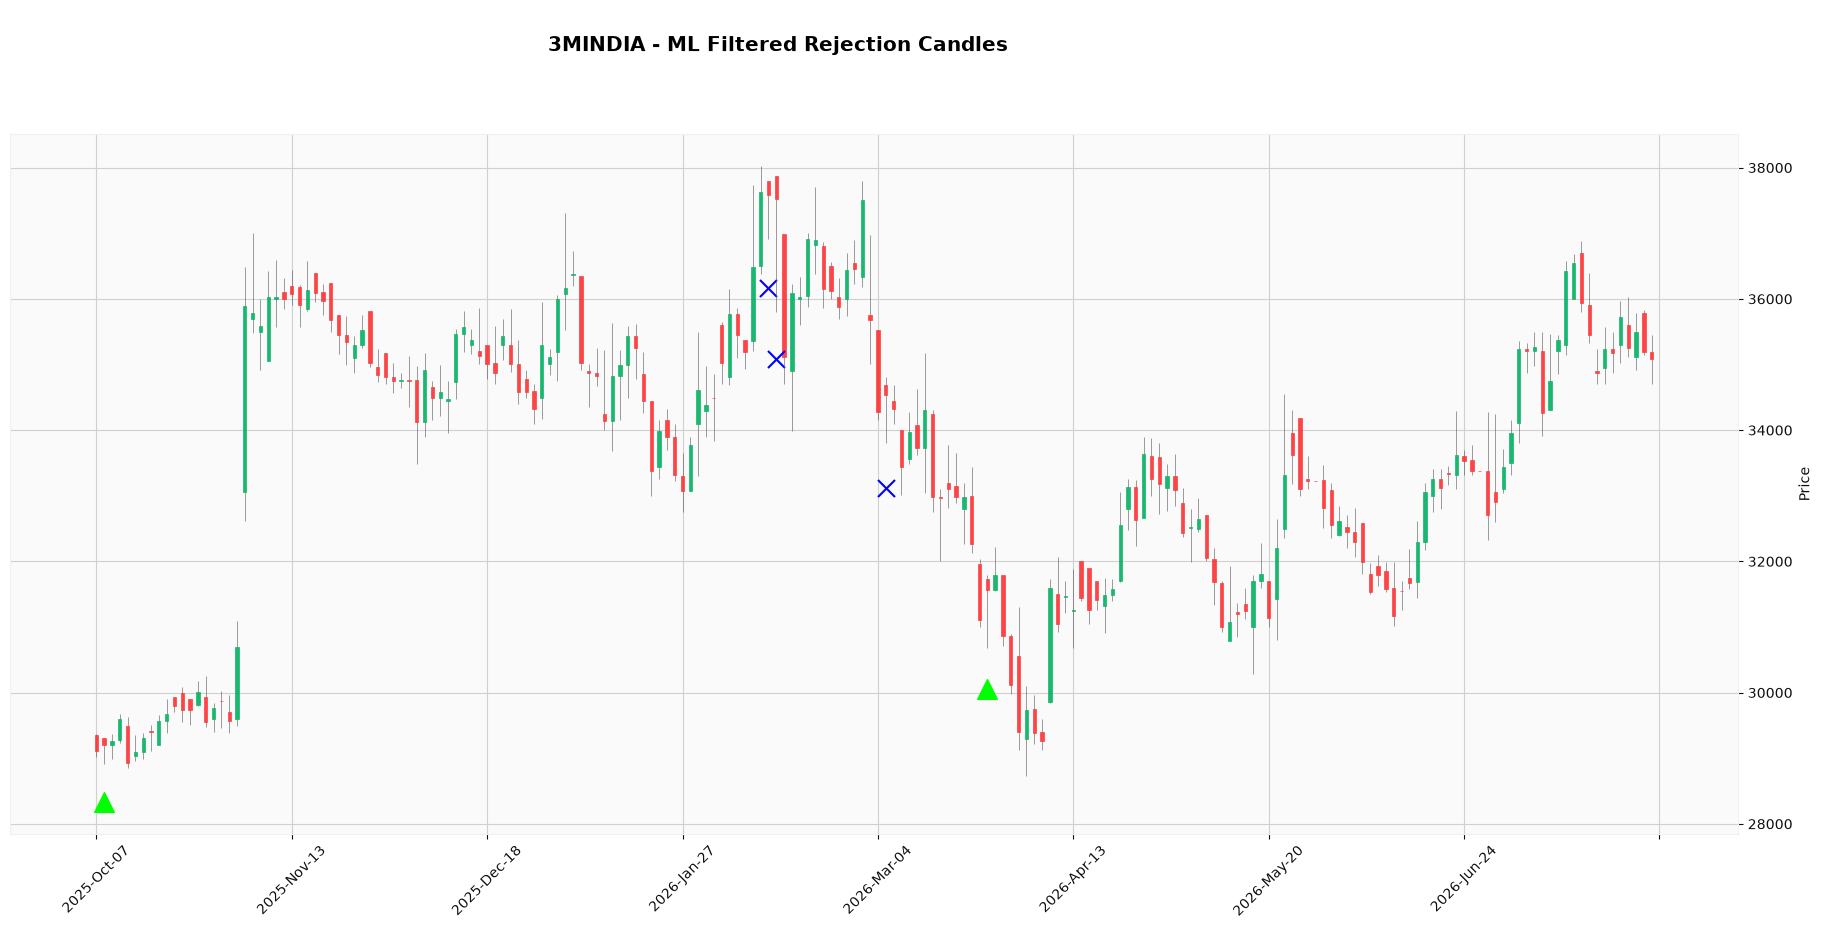

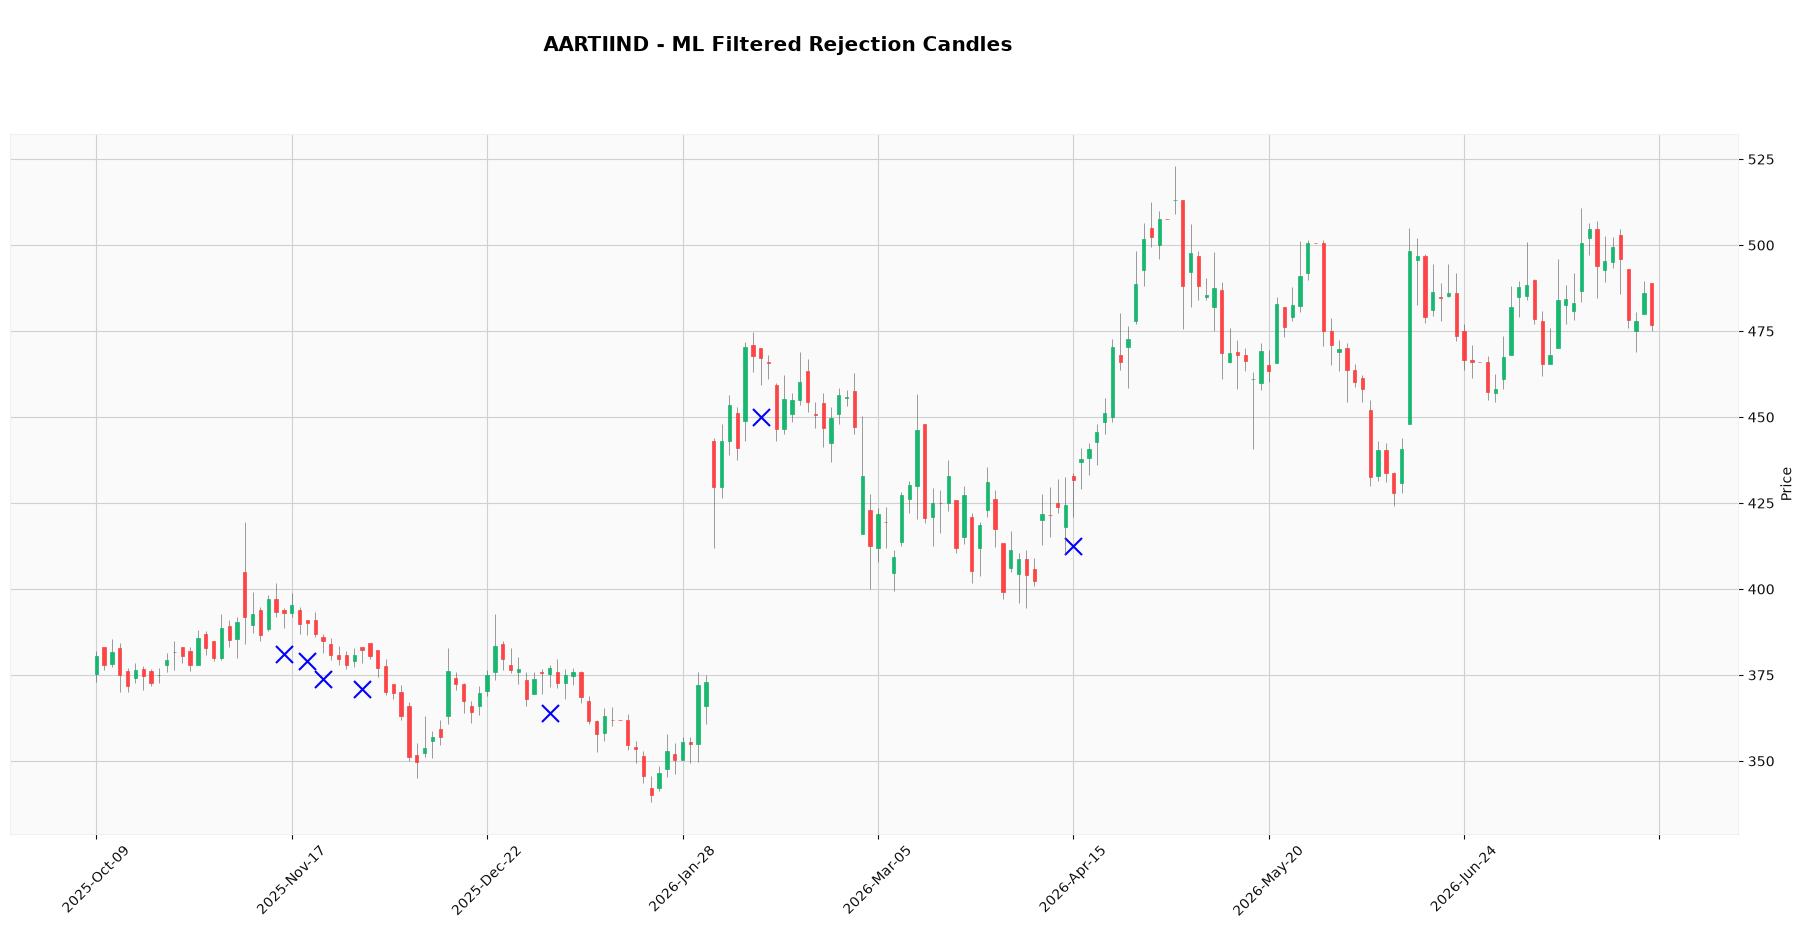

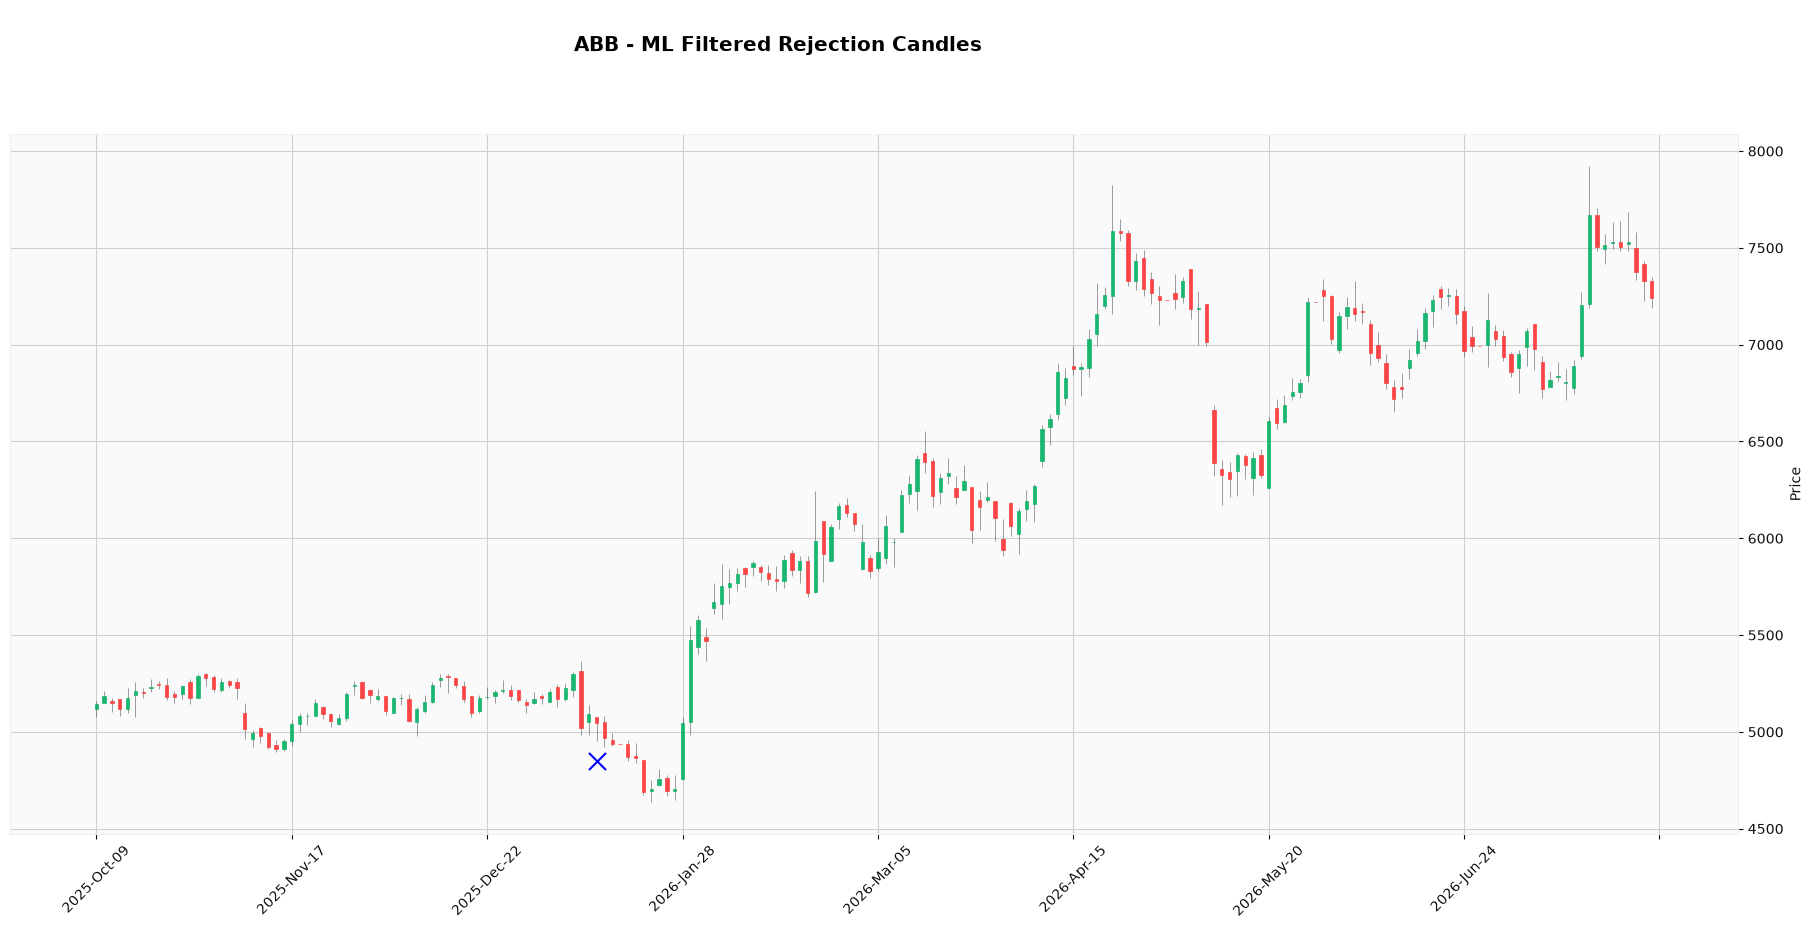

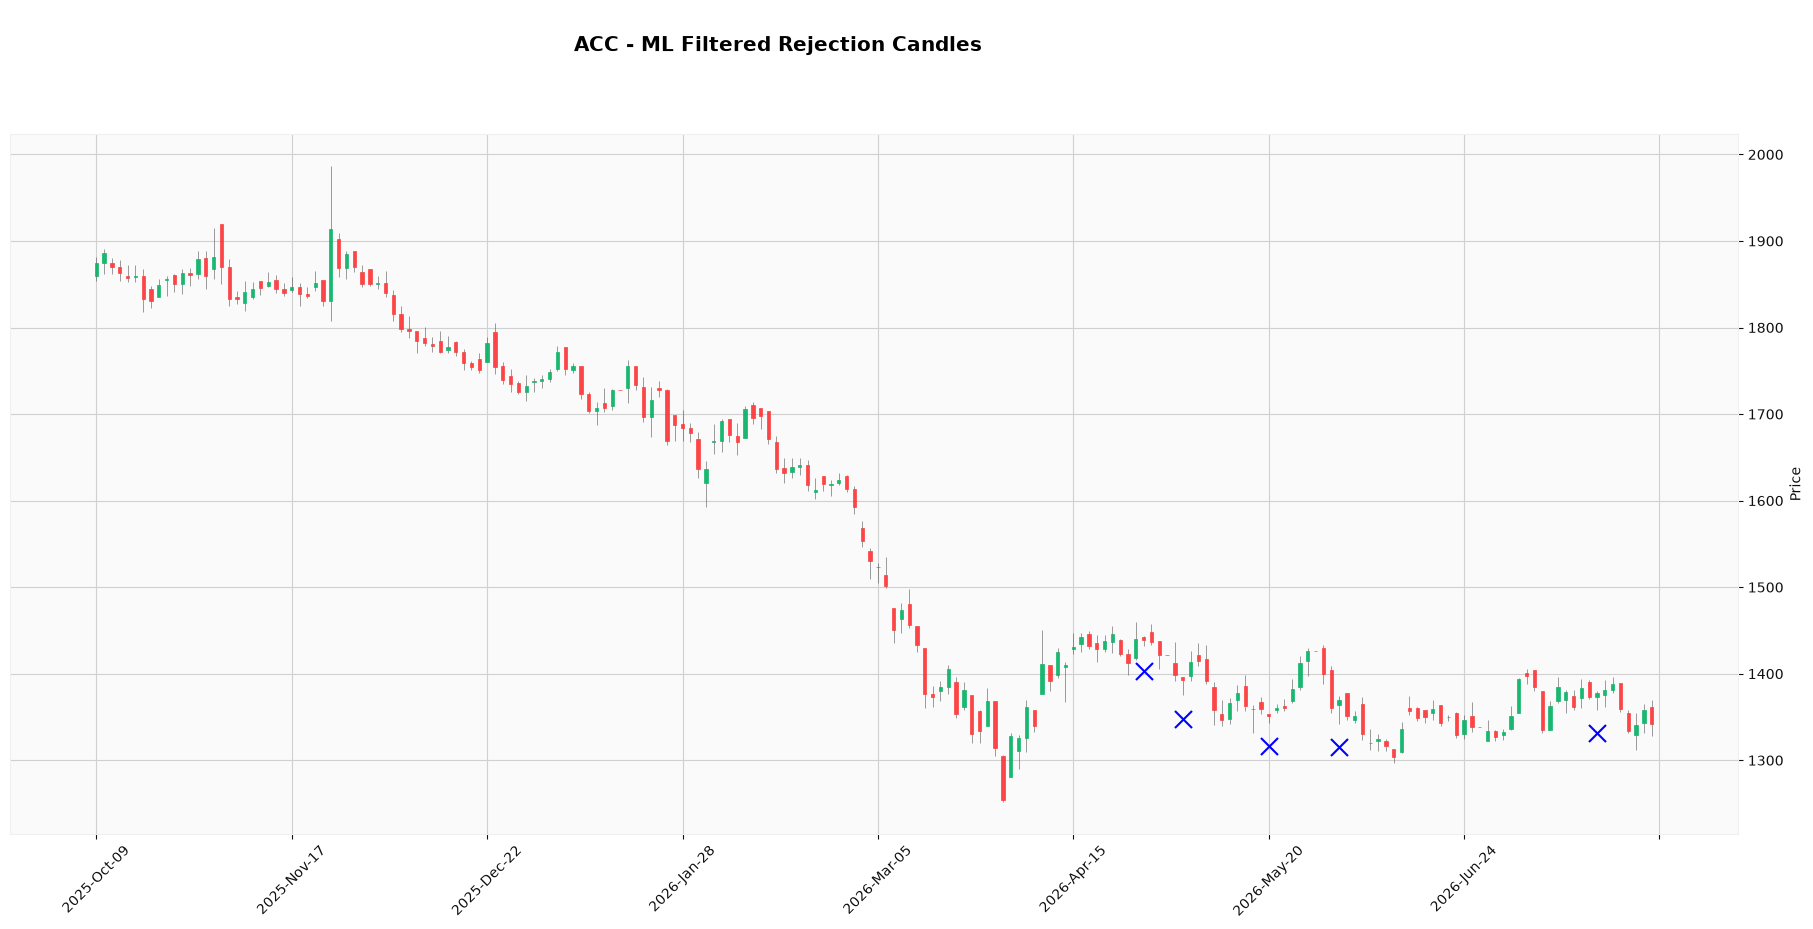

In [8]:
# 8. Visualizing Candlesticks for All Samples (Matplotlib Full Wide)
# We plot the last 200 days for every stock in the sample

for symbol in SAMPLE_STOCKS:
    df_plot = processed_data[processed_data['Symbol'] == symbol].tail(200).copy()
    df_plot.set_index('Date', inplace=True)
    
    # Identify signals within this slice
    sig_approved = filtered_signals[(filtered_signals['Symbol'] == symbol) & (filtered_signals['Date'].isin(df_plot.index))]
    sig_rejected = signals[(signals['ML_Prediction'] == 0) & (signals['Symbol'] == symbol) & (signals['Date'].isin(df_plot.index))]
    
    # Create marker arrays (must match length of df_plot, padded with NaN)
    approved_markers = [row['Low'] * 0.98 if idx in sig_approved['Date'].values else np.nan for idx, row in df_plot.iterrows()]
    rejected_markers = [row['Low'] * 0.98 if idx in sig_rejected['Date'].values else np.nan for idx, row in df_plot.iterrows()]
    
    # Overlay plots
    apds = []
    if not all(np.isnan(approved_markers)):
        apds.append(mpf.make_addplot(approved_markers, type='scatter', markersize=200, marker='^', color='lime'))
    if not all(np.isnan(rejected_markers)):
        apds.append(mpf.make_addplot(rejected_markers, type='scatter', markersize=150, marker='x', color='blue')) # Changed to blue so it doesn't clash with red candles
        
    mpf.plot(df_plot, type='candle', addplot=apds, style='yahoo', 
             title=f'\n{symbol} - ML Filtered Rejection Candles', 
             figsize=(24, 10), volume=False)
